# Tugas Besar 1 Machine Learning
Analisis dan Pemodelan menggunakan dataset Global Student Placement & Salary Dataset menggunakan FFNN yang telah dibuat.

### Data Preprocessing

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

DATA_PATH = '../data/datasetml_2026.csv'
TARGET_COL = 'placement_status'

df = pd.read_csv(DATA_PATH)
X_df = df.drop(columns=[TARGET_COL]).copy()
y_series = df[TARGET_COL].copy()

print('Dataset path:', DATA_PATH)
print('Data shape:', df.shape)
print('Jumlah fitur awal:', X_df.shape[1])
print('Unique target raw:', sorted(y_series.astype(str).str.strip().unique()))

Dataset path: ../data/datasetml_2026.csv
Data shape: (10000, 12)
Jumlah fitur awal: 11
Unique target raw: ['Not Placed', 'Placed']


In [32]:
target_values = sorted(y_series.astype(str).str.strip().unique())
print('Unique target:', target_values)

if 'Placed' in target_values and 'Not Placed' in target_values:
    target_mapping = {'Not Placed': 0, 'Placed': 1}
else:
    target_mapping = {target_values[0]: 0, target_values[1]: 1}

y = y_series.astype(str).str.strip().map(target_mapping).astype(float).values.reshape(-1, 1)

cat_cols = X_df.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)

print('Target mapping:', target_mapping)
print('Jumlah fitur setelah encoding:', X_encoded.shape[1])
print('Contoh kolom fitur:', X_encoded.columns[:10].tolist())

Unique target: ['Not Placed', 'Placed']
Target mapping: {'Not Placed': 0, 'Placed': 1}
Jumlah fitur setelah encoding: 23
Contoh kolom fitur: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score', 'college_tier_Tier 2', 'college_tier_Tier 3', 'country_Germany', 'country_India']


C:\Users\kefas\AppData\Local\Temp\ipykernel_10640\319105158.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_df.select_dtypes(include=['object', 'category']).columns.tolist()


In [33]:
X_np = X_encoded.values.astype(float)
y_np = y.astype(float)

# 70/15/15
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_np, y_np, test_size=0.15, random_state=42, stratify=y_np.ravel()
 )

val_ratio_from_trainval = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio_from_trainval, random_state=42, stratify=y_trainval.ravel()
 )

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (7000, 23) (7000, 1)
Val  : (1500, 23) (1500, 1)
Test : (1500, 23) (1500, 1)


### Helper Function
Helper untuk visualisasi loss, distribusi bobot, dan distribusi gradien bobot

In [34]:
def _finite_series(values):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 0:
        arr = arr.reshape(1)
    return arr[np.isfinite(arr)]


def plot_loss_curves(history, title='Loss Curve'):
    train_loss = _finite_series(history.get('loss', []))
    val_loss = _finite_series(history.get('val_loss', []))

    if train_loss.size == 0 and val_loss.size == 0:
        print(f'{title}: loss kosong/NaN, plot dilewati.')
        return

    plt.figure(figsize=(7, 4))
    if train_loss.size > 0:
        plt.plot(train_loss, label='train_loss')
    if val_loss.size > 0:
        plt.plot(val_loss, label='val_loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def to_binary(y_score, threshold=0.5):
    return (y_score >= threshold).astype(int)


def evaluate_binary(y_true, y_score, threshold=0.5):
    y_true_1d = y_true.ravel().astype(int)
    y_pred_1d = to_binary(y_score.ravel(), threshold=threshold)
    return {
        'accuracy': accuracy_score(y_true_1d, y_pred_1d),
        'precision': precision_score(y_true_1d, y_pred_1d, zero_division=0),
        'recall': recall_score(y_true_1d, y_pred_1d, zero_division=0),
        'f1': f1_score(y_true_1d, y_pred_1d, zero_division=0),
    }

In [35]:

def plot_weight_and_grad_distribution(model, layer_idx=0, num_bins=50):
    param_layers = [lyr for lyr in model.layers if hasattr(lyr, 'get_parameters')]
    if len(param_layers) == 0:
        print('Model tidak punya layer berparameter.')
        return

    safe_idx = max(0, min(layer_idx, len(param_layers) - 1))
    layer = param_layers[safe_idx]
    weight_tensor = layer.get_parameters()[0]

    w = np.asarray(weight_tensor.data, dtype=float).ravel()
    g = np.asarray(weight_tensor.grad, dtype=float).ravel()

    w = w[np.isfinite(w)]
    g = g[np.isfinite(g)]

    if w.size == 0:
        print('Bobot kosong/NaN')
    else:
        plt.figure(figsize=(6, 4))
        plt.hist(w, bins=num_bins)
        plt.title(f'Weight distribution for param-layer {safe_idx}')
        plt.xlabel('Weight')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    if g.size == 0:
        print('Gradien kosong/NaN')
    else:
        plt.figure(figsize=(6, 4))
        plt.hist(g, bins=num_bins)
        plt.title(f'Gradient weight distribution for param-layer {safe_idx}')
        plt.xlabel('Gradient weight')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

### Pengujian 1.1: Pengaruh Depth dan Width

In [36]:
from ffnn import FeedForwardNeuralNetwork
from module.layer import Layer
from module.activation import Linear, ReLU, Sigmoid, Tanh
from module.loss_function import BinaryCrossEntropy
from module.optimizer import SGD


def build_ffnn(
    input_dim,
    hidden_layers,
    hidden_activation='relu',
    output_dim=1,
    lr=0.01,
    l1=0.0,
    l2=0.0,
    seed=42,
    verbose=True,
):
    act_map = {
        'linear': Linear,
        'relu': ReLU,
        'sigmoid': Sigmoid,
        'tanh': Tanh,
    }
    act_cls = act_map.get(hidden_activation, ReLU)

    model = FeedForwardNeuralNetwork(verbose=verbose, seed=seed)

    prev_dim = input_dim
    for h in hidden_layers:
        model.add(Layer(prev_dim, h, initialization_type='xavier'))
        model.add(act_cls())
        prev_dim = h

    # Output binary classification
    model.add(Layer(prev_dim, output_dim, initialization_type='xavier'))
    model.add(Sigmoid())

    params = []
    for lyr in model.layers:
        if hasattr(lyr, 'get_parameters'):
            params.extend(lyr.get_parameters())

    optimizer = SGD(params, learning_rate=lr, l1_lambda=l1, l2_lambda=l2)
    model.compile(loss_function=BinaryCrossEntropy(), optimizer=optimizer)
    return model


def train_and_eval(
    name,
    hidden_layers,
    hidden_activation='relu',
    lr=0.01,
    l1=0.0,
    l2=0.0,
    epochs=100,
    batch_size=32,
    distribution_layer_idx=0,
    show_distribution=False,
):
    model = build_ffnn(
        input_dim=X_train.shape[1],
        hidden_layers=hidden_layers,
        hidden_activation=hidden_activation,
        lr=lr,
        l1=l1,
        l2=l2,
        verbose=False,
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
    )

    # Untuk tuning hyperparameter gunakan VALIDATION, bukan TEST.
    y_score_val = model.predict(X_val).data
    metrics_val = evaluate_binary(y_val, y_score_val)

    row = {
        'name': name,
        'hidden_layers': hidden_layers,
        'activation': hidden_activation,
        'lr': lr,
        'l1': l1,
        'l2': l2,
        'accuracy': metrics_val['accuracy'],
        'precision': metrics_val['precision'],
        'recall': metrics_val['recall'],
        'f1': metrics_val['f1'],
        'history': history,
        'model': model,
    }

    if show_distribution:
        plot_weight_and_grad_distribution(model, layer_idx=distribution_layer_idx, num_bins=40)

    return row

#### Eksperimen Width & Depth

In [37]:
EPOCHS = 80
BATCH_SIZE = 32

width_variants = [
    [16, 16],
    [32, 32],
    [64, 64],
]

depth_variants = [
    [32],
    [32, 32, 32],
    [32, 32, 32, 32, 32],
]

results_depth_width = []

for hidden in width_variants:
    name = f'Width Test hidden={hidden} (depth tetap=2)'
    row = train_and_eval(
        name=name,
        hidden_layers=hidden,
        hidden_activation='relu',
        lr=0.01,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )
    results_depth_width.append(row)

for hidden in depth_variants:
    name = f'Depth Test hidden={hidden} (width tetap=32)'
    row = train_and_eval(
        name=name,
        hidden_layers=hidden,
        hidden_activation='relu',
        lr=0.01,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )
    results_depth_width.append(row)

#### Hasil Pengujian Depth vs Width

,name,hidden_layers,activation,lr,l1,l2,accuracy,precision,recall,f1
0,Depth Test hidden=[32] (width tetap=32),[32],relu,0.01,0.0,0.0,0.744667,0.760116,0.854821,0.804691
1,"Width Test hidden=[32, 32] (depth tetap=2)","[32, 32]",relu,0.01,0.0,0.0,0.740667,0.757722,0.850488,0.801429
2,"Width Test hidden=[16, 16] (depth tetap=2)","[16, 16]",relu,0.01,0.0,0.0,0.738000,0.756286,0.847237,0.799182
3,"Width Test hidden=[64, 64] (depth tetap=2)","[64, 64]",relu,0.01,0.0,0.0,0.736000,0.758587,0.837486,0.796087
4,"Depth Test hidden=[32, 32, 32] (width tetap=32)","[32, 32, 32]",relu,0.01,0.0,0.0,0.734667,0.758112,0.835320,0.794845
5,"Depth Test hidden=[32, 32, 32, 32, 32] (width ...","[32, 32, 32, 32, 32]",relu,0.01,0.0,0.0,0.734667,0.767040,0.816901,0.791186


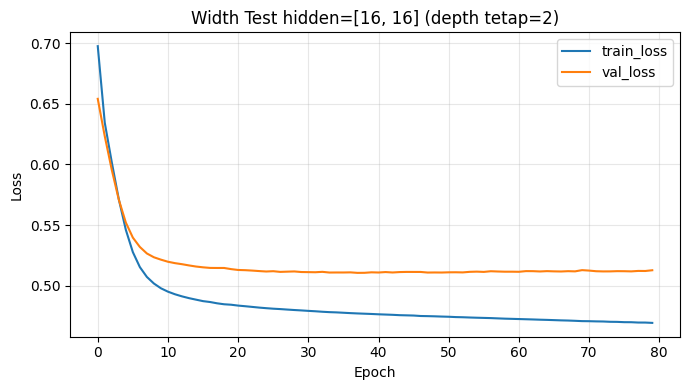

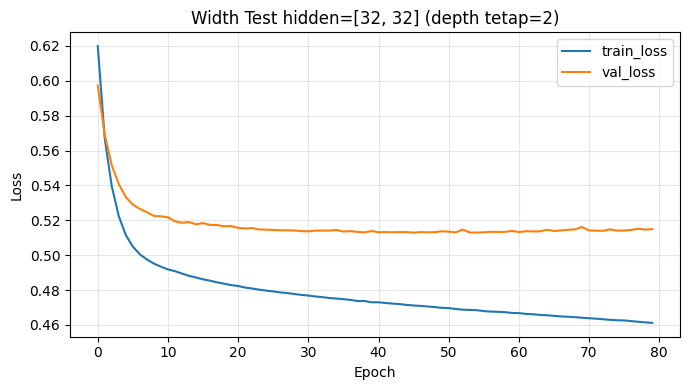

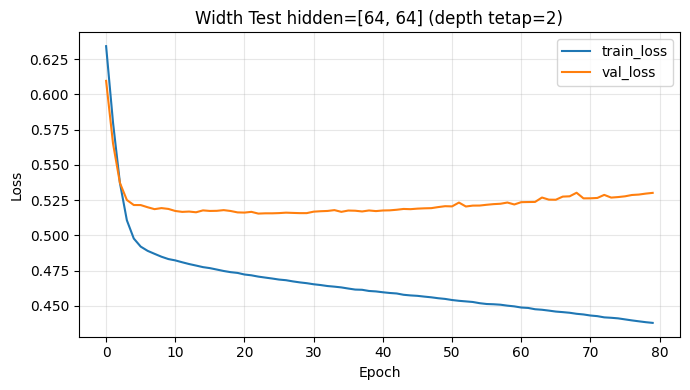

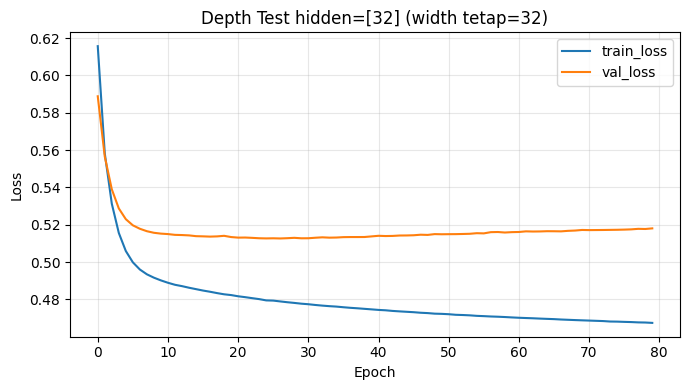

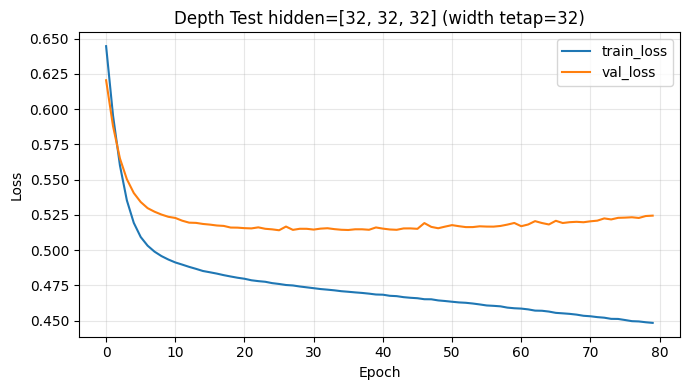

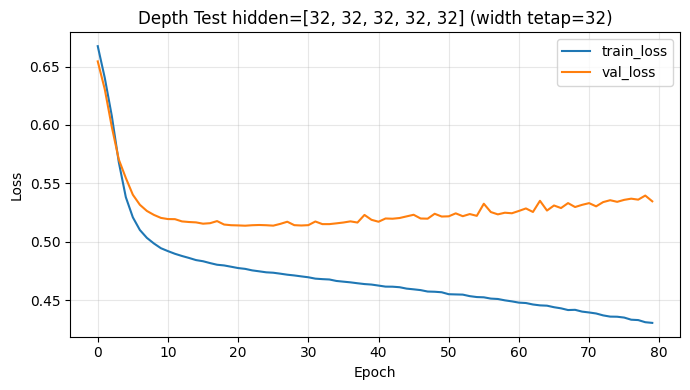

In [38]:
df_depth_width = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['history', 'model']}
    for row in results_depth_width
]).sort_values('f1', ascending=False).reset_index(drop=True)

display(df_depth_width)

for row in results_depth_width:
    plot_loss_curves(row['history'], title=row['name'])

### Pengujian 1.2: Pengaruh Fungsi Aktivasi Hidden Layer

In [39]:
base_hidden = [64, 32, 16]
activation_variants = ['linear', 'relu', 'sigmoid', 'tanh']

results_activation = []

for act in activation_variants:
    row = train_and_eval(
        name=f'Activation={act}',
        hidden_layers=base_hidden,
        hidden_activation=act,
        lr=0.01,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )
    results_activation.append(row)

#### Hasil Pengujian Pengaruh Aktivasi Hidden Layer

,name,hidden_layers,activation,lr,l1,l2,accuracy,precision,recall,f1
0,Activation=sigmoid,"[64, 32, 16]",sigmoid,0.01,0.0,0.0,0.751333,0.768031,0.853738,0.808620
1,Activation=linear,"[64, 32, 16]",linear,0.01,0.0,0.0,0.751333,0.769608,0.850488,0.808029
2,Activation=tanh,"[64, 32, 16]",tanh,0.01,0.0,0.0,0.734667,0.762763,0.825569,0.792924
3,Activation=relu,"[64, 32, 16]",relu,0.01,0.0,0.0,0.736667,0.771605,0.812568,0.791557


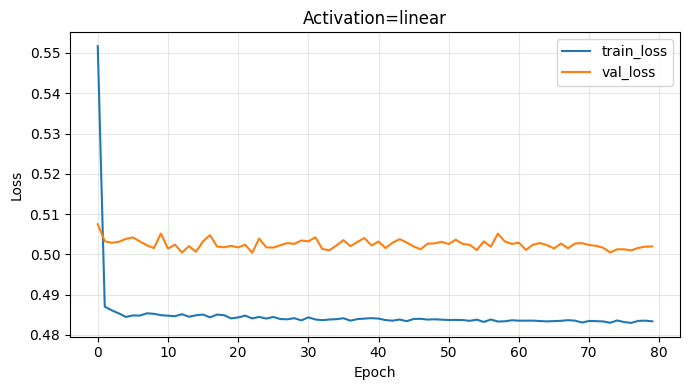

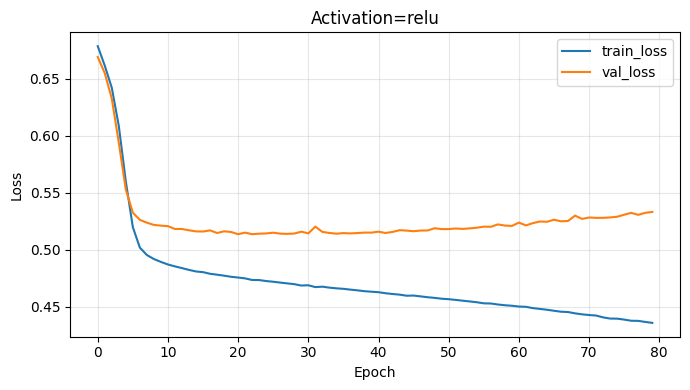

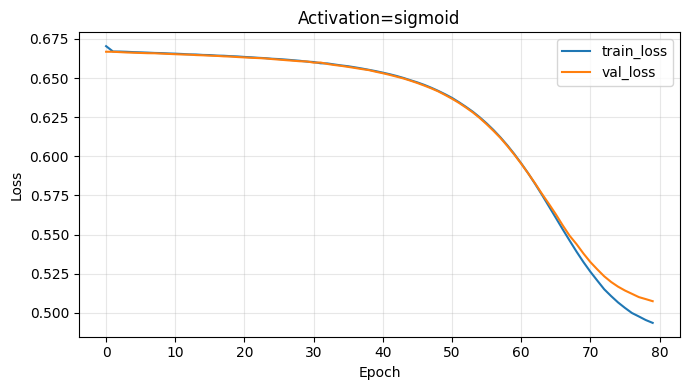

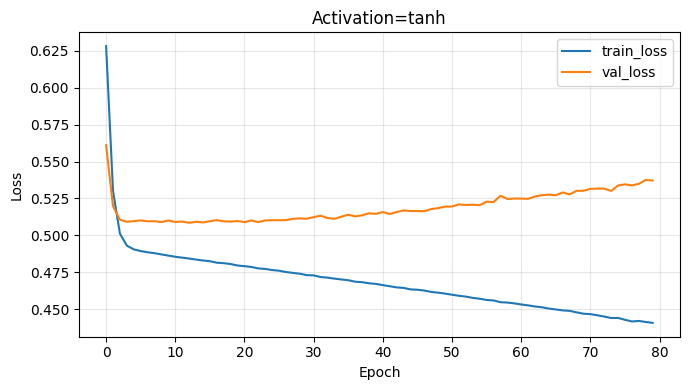

Distribusi bobot & gradien -> Activation=linear


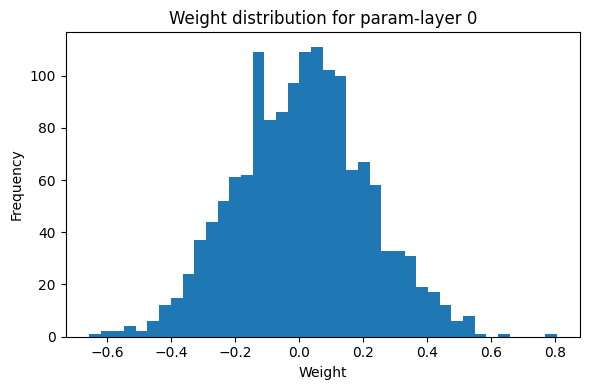

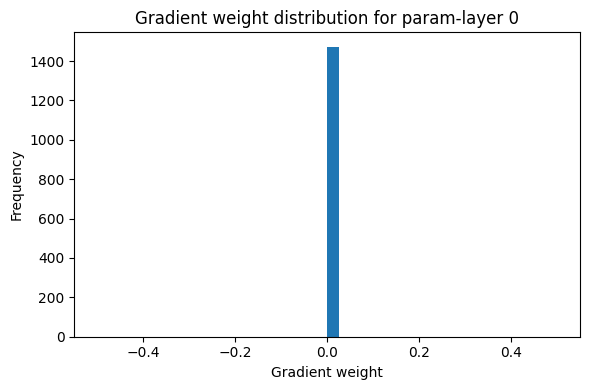

Distribusi bobot & gradien -> Activation=relu


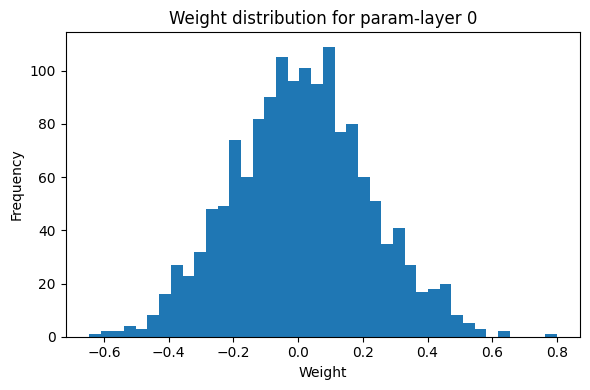

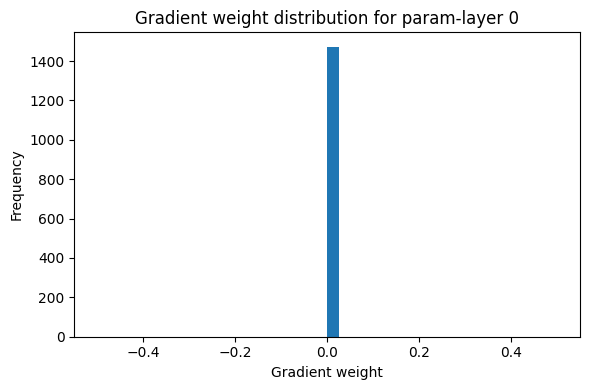

Distribusi bobot & gradien -> Activation=sigmoid


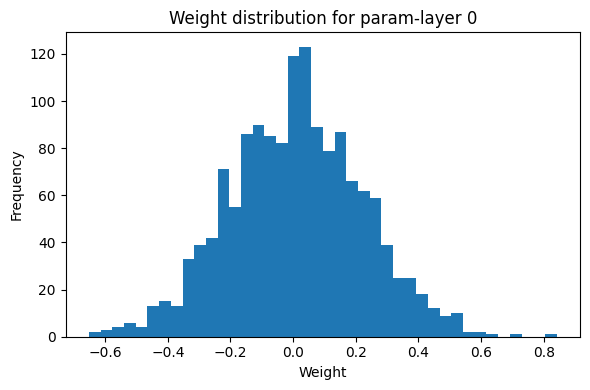

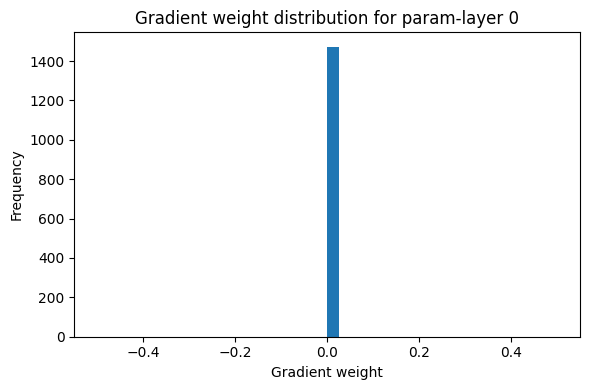

Distribusi bobot & gradien -> Activation=tanh


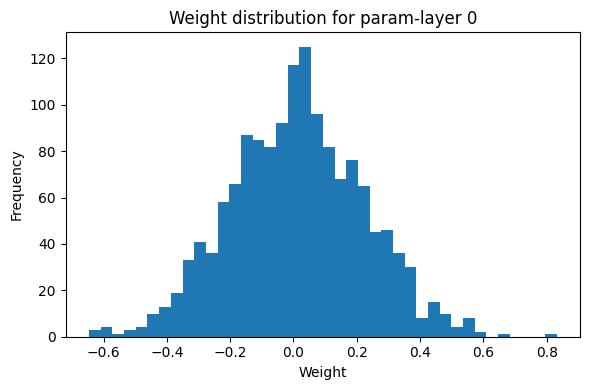

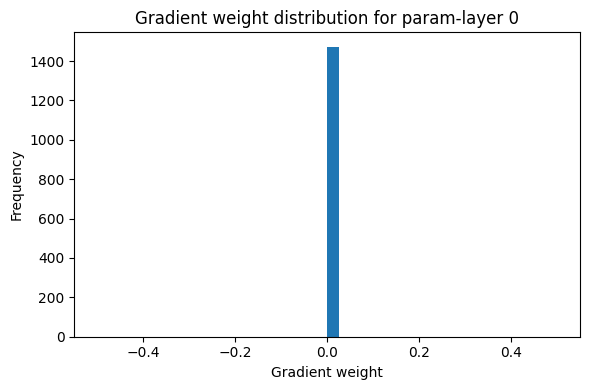

Catatan: lihat aktivasi mana yang paling stabil dan konsisten pada validation loss.


In [ ]:
df_activation = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['history', 'model']}
    for row in results_activation
]).sort_values('f1', ascending=False).reset_index(drop=True)

display(df_activation)

for row in results_activation:
    plot_loss_curves(row['history'], title=row['name'])

for row in results_activation:
    print(f"Distribusi bobot & gradien -> {row['name']}")
    plot_weight_and_grad_distribution(row['model'], layer_idx=0, num_bins=40)

### Pengujian 1.3: Pengaruh Learning Rate

In [41]:
lr_variants = [1e-1, 1e-2, 1e-3]
results_lr = []

for lr in lr_variants:
    row = train_and_eval(
        name=f'Learning Rate={lr}',
        hidden_layers=base_hidden,
        hidden_activation='relu',
        lr=lr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )
    results_lr.append(row)

#### Hasil Pengujian Learning Rate

,name,hidden_layers,activation,lr,l1,l2,accuracy,precision,recall,f1
0,Learning Rate=0.01,"[64, 32, 16]",relu,0.010,0.0,0.0,0.736667,0.771605,0.812568,0.791557
1,Learning Rate=0.001,"[64, 32, 16]",relu,0.001,0.0,0.0,0.728000,0.752699,0.830986,0.789907
2,Learning Rate=0.1,"[64, 32, 16]",relu,0.100,0.0,0.0,0.670000,0.738839,0.717226,0.727872


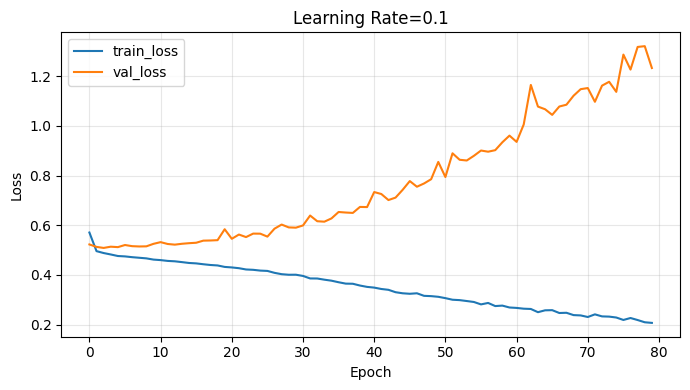

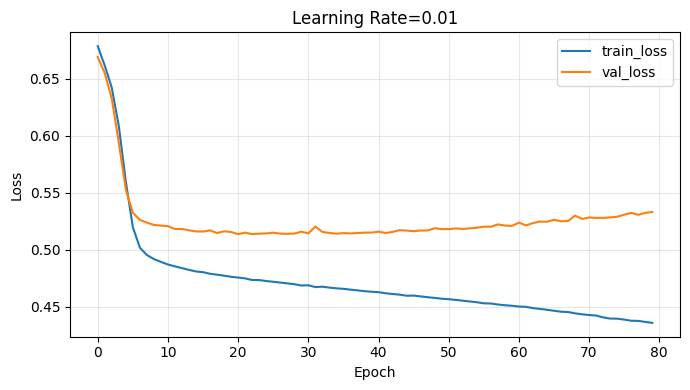

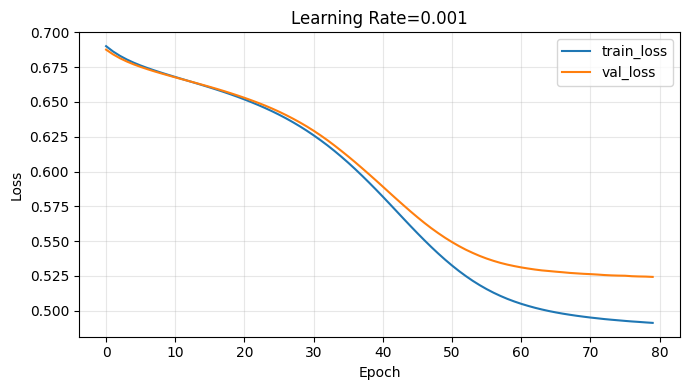

Distribusi bobot & gradien -> Learning Rate=0.1


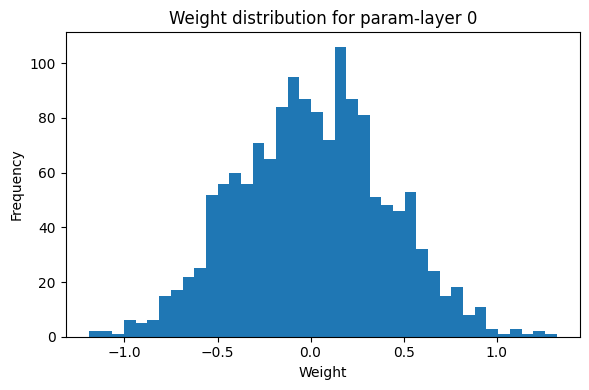

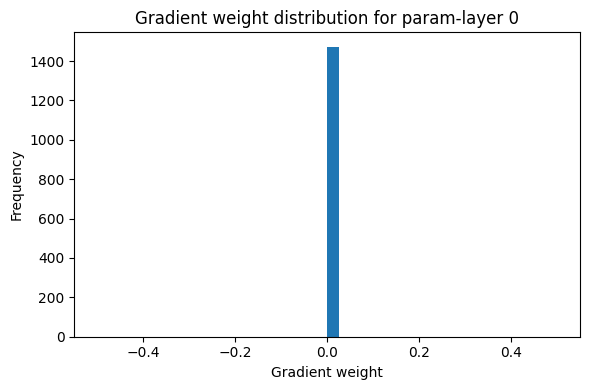

Distribusi bobot & gradien -> Learning Rate=0.01


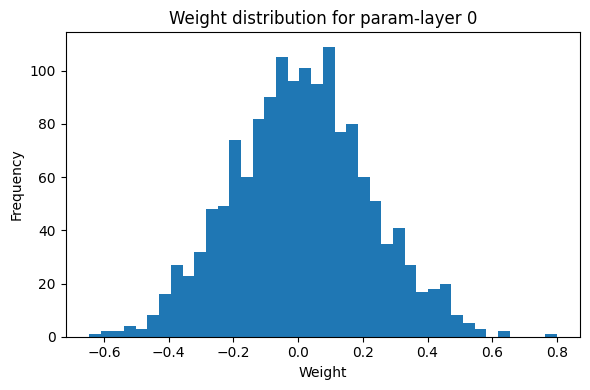

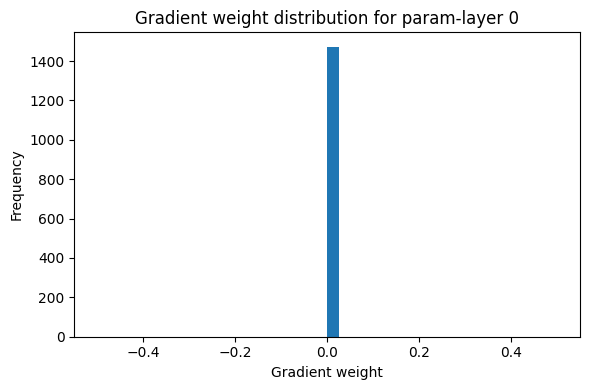

Distribusi bobot & gradien -> Learning Rate=0.001


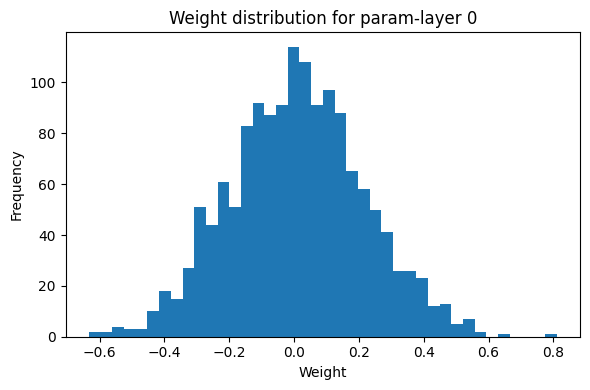

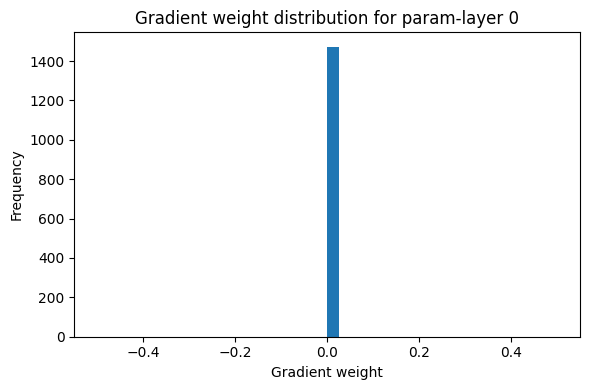

Catatan: learning rate terlalu besar biasanya bikin loss tidak stabil.


In [ ]:
df_lr = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['history', 'model']}
    for row in results_lr
]).sort_values('f1', ascending=False).reset_index(drop=True)

display(df_lr)

for row in results_lr:
    plot_loss_curves(row['history'], title=row['name'])

for row in results_lr:
    print(f"Distribusi bobot & gradien -> {row['name']}")
    plot_weight_and_grad_distribution(row['model'], layer_idx=0, num_bins=40)

### Pengujian 2: Pengaruh Regularisasi

In [43]:
reg_configs = [
    {'name': 'No Regularization', 'l1': 0.0, 'l2': 0.0},
    {'name': 'L1 Regularization', 'l1': 1e-4, 'l2': 0.0},
    {'name': 'L2 Regularization', 'l1': 0.0, 'l2': 1e-4},
]

results_reg = []

for cfg in reg_configs:
    row = train_and_eval(
        name=cfg['name'],
        hidden_layers=base_hidden,
        hidden_activation='relu',
        lr=0.01,
        l1=cfg['l1'],
        l2=cfg['l2'],
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
    )
    results_reg.append(row)

,name,hidden_layers,activation,lr,l1,l2,accuracy,precision,recall,f1
0,No Regularization,"[64, 32, 16]",relu,0.01,0.0000,0.0000,0.736667,0.771605,0.812568,0.791557
1,L1 Regularization,"[64, 32, 16]",relu,0.01,0.0001,0.0000,0.736667,0.772165,0.811484,0.791337
2,L2 Regularization,"[64, 32, 16]",relu,0.01,0.0000,0.0001,0.734667,0.770340,0.810401,0.789863


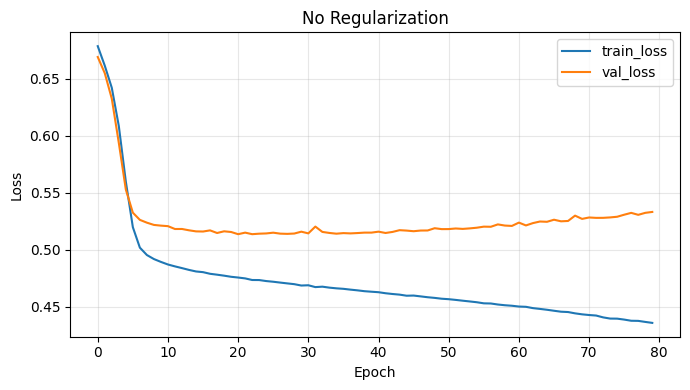

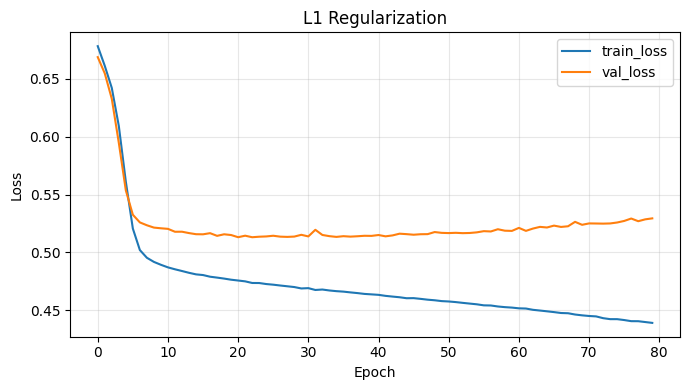

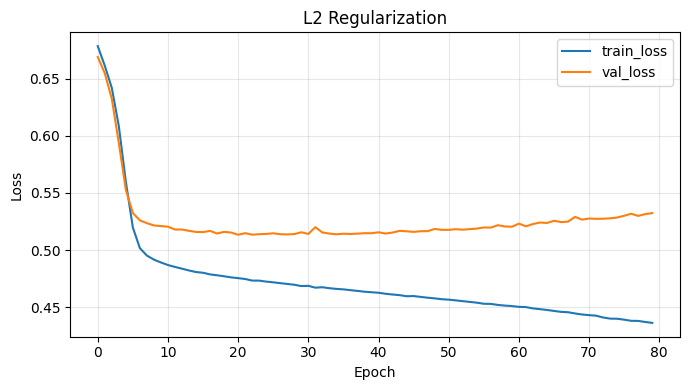

Distribusi bobot & gradien -> No Regularization


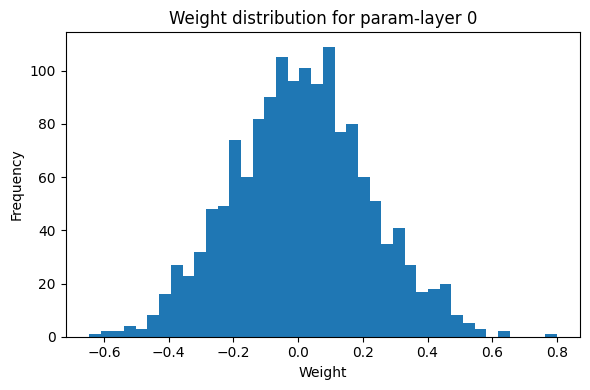

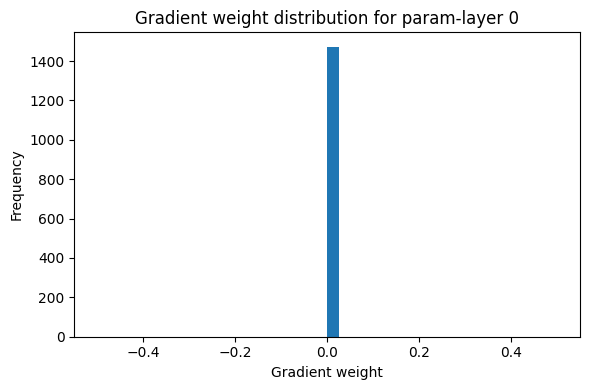

Distribusi bobot & gradien -> L1 Regularization


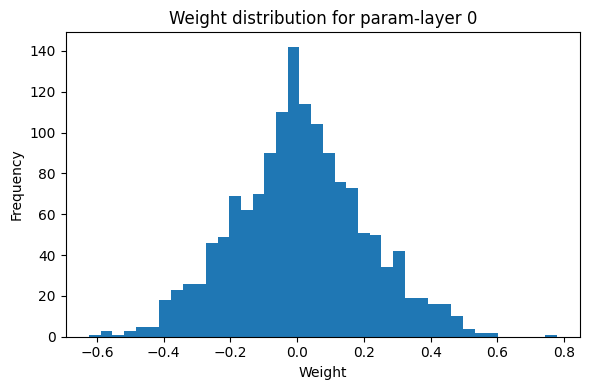

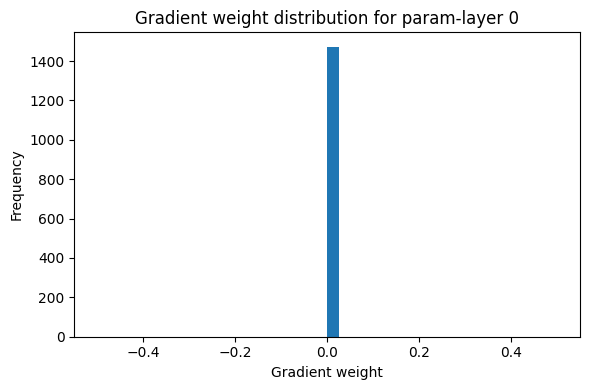

Distribusi bobot & gradien -> L2 Regularization


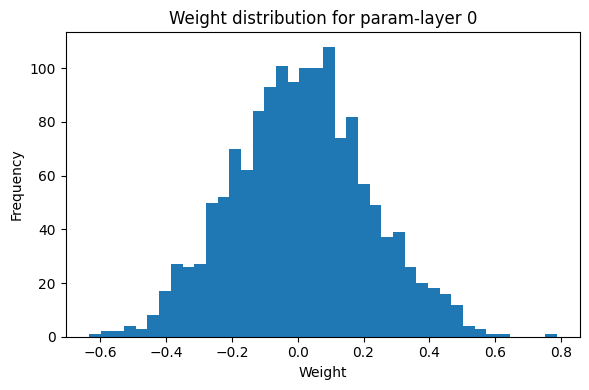

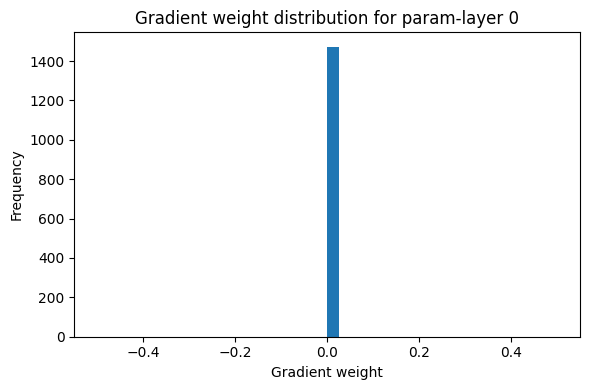

Catatan: L1 cenderung mendorong sparsity, L2 cenderung mengecilkan bobot.


In [ ]:
df_reg = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['history', 'model']}
    for row in results_reg
]).sort_values('f1', ascending=False).reset_index(drop=True)

display(df_reg)

for row in results_reg:
    plot_loss_curves(row['history'], title=row['name'])

for row in results_reg:
    print(f"Distribusi bobot & gradien -> {row['name']}")
    plot_weight_and_grad_distribution(row['model'], layer_idx=0, num_bins=40)

## Pengujian 3: Uji Perbandingan dengan scikit-learn

In [47]:
from sklearn.neural_network import MLPClassifier

# Pilih model terbaik berdasarkan skor VALIDATION dari seluruh eksperimen.
all_candidates = results_depth_width + results_activation + results_lr + results_reg
best_row = max(all_candidates, key=lambda r: r['f1'])
print('Best config (validation):', best_row['name'])

best_hidden = list(best_row['hidden_layers'])
best_activation = best_row['activation']
best_lr = best_row['lr']
best_l1 = best_row['l1']
best_l2 = best_row['l2']

# Mapping nama aktivasi custom -> nama aktivasi sklearn
activation_map_sklearn = {
    'linear': 'identity',
    'sigmoid': 'logistic',
    'tanh': 'tanh',
    'relu': 'relu',
}
sk_activation = activation_map_sklearn.get(best_activation, 'relu')

# Gabungkan train+val untuk training final, test dipakai sekali di akhir.
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.vstack([y_train, y_val])

# Final FFNN
ffnn_final = build_ffnn(
    input_dim=X_train_full.shape[1],
    hidden_layers=best_hidden,
    hidden_activation=best_activation,
    lr=best_lr,
    l1=best_l1,
    l2=best_l2,
    verbose=False,
 )
_ = ffnn_final.fit(
    X_train_full,
    y_train_full,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=None,
 )
y_pred_ffnn = ffnn_final.predict(X_test).data
metrics_ffnn_test = evaluate_binary(y_test, y_pred_ffnn)

# Final sklearn (setara dengan konfigurasi terbaik)
sk_mlp = MLPClassifier(
    hidden_layer_sizes=tuple(best_hidden),
    activation=sk_activation,
    solver='sgd',
    alpha=0.0,
    momentum=0.0,
    learning_rate='constant',
    learning_rate_init=best_lr,
    batch_size=BATCH_SIZE,
    max_iter=EPOCHS,
    early_stopping=False,
    shuffle=True,
    random_state=42,
    n_iter_no_change=EPOCHS,
 )
y_train_sklearn = y_train_full.ravel().astype(int)
y_test_sklearn = y_test.ravel().astype(int)

sk_mlp.fit(X_train_full, y_train_sklearn)
y_pred_sklearn = sk_mlp.predict(X_test)
metrics_sklearn = {
    'accuracy': accuracy_score(y_test_sklearn, y_pred_sklearn),
    'precision': precision_score(y_test_sklearn, y_pred_sklearn, zero_division=0),
    'recall': recall_score(y_test_sklearn, y_pred_sklearn, zero_division=0),
    'f1': f1_score(y_test_sklearn, y_pred_sklearn, zero_division=0),
}

print('Sklearn activation:', sk_activation)
print('FFNN test metrics:', metrics_ffnn_test)
print('Sklearn test metrics:', metrics_sklearn)

Best config (validation): Activation=sigmoid
Sklearn activation: logistic
FFNN test metrics: {'accuracy': 0.7586666666666667, 'precision': 0.7882836587872559, 'recall': 0.8309859154929577, 'f1': 0.8090717299578059}
Sklearn test metrics: {'accuracy': 0.6153333333333333, 'precision': 0.6153333333333333, 'recall': 1.0, 'f1': 0.7618654560462237}


C:\Users\kefas\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


In [49]:
comparison = pd.DataFrame([
    {
        'Model': 'FFNN Scratch (final test)',
        'Accuracy': metrics_ffnn_test['accuracy'],
        'Precision': metrics_ffnn_test['precision'],
        'Recall': metrics_ffnn_test['recall'],
        'F1': metrics_ffnn_test['f1'],
    },
    {
        'Model': 'Sklearn MLPClassifier (final test)',
        'Accuracy': metrics_sklearn['accuracy'],
        'Precision': metrics_sklearn['precision'],
        'Recall': metrics_sklearn['recall'],
        'F1': metrics_sklearn['f1'],
    },
])

display(comparison)

,Model,Accuracy,Precision,Recall,F1
0,FFNN Scratch (final test),0.758667,0.788284,0.830986,0.809072
1,Sklearn MLPClassifier (final test),0.615333,0.615333,1.000000,0.761865


## 8. Ringkasan dan Kesimpulan